# Assignment 1 (20th March)

## Problem 1.1: Gradient Boosting Implementation(30 points)
Implement gradient boosting from scratch for regression:

• Use decision tree stumps as base learners.

• Implement learning rate and number of estimators as hyperparameters.

• Test on the California Housing dataset.

• Compare performance with scikit-learn’s GradientBoostingRegressor.

In [20]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

In [21]:
np.random.seed(123)

In [22]:
class GB:
    def __init__(self, n_estimators=100, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.init_prediction = 0.0
        self.stumps = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.init_prediction = float(y.mean())
        y_pred = np.full(y.shape, self.init_prediction, dtype=float)
        self.stumps = []

        for _ in range(self.n_estimators):
            residuals = y - y_pred
            stump = DecisionTreeRegressor(max_depth=1)
            stump.fit(X, residuals)
            update = stump.predict(X)
            y_pred += self.learning_rate * update
            self.stumps.append(stump)

        return self

    def predict(self, X):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        y_pred = np.full(X.shape[0], self.init_prediction, dtype=float)
        for stump in self.stumps:
            y_pred += self.learning_rate * stump.predict(X)
        return y_pred

### Data download


In [23]:
fetch_california_housing()

/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:992)>

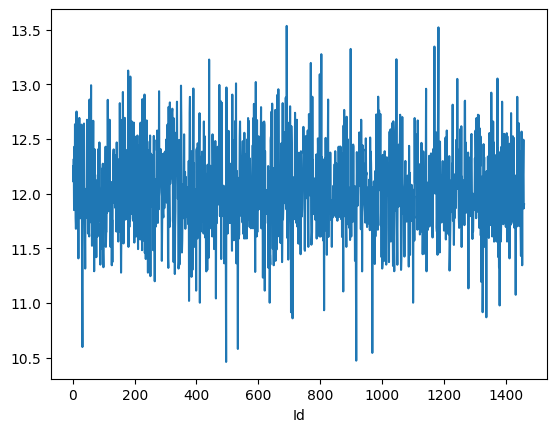

In [ ]:
data.SalePrice.apply(np.log).plot()
plt.show()


In [ ]:
data = pd.read_csv("data/house_prices.csv", index_col=0)#fetch_california_housing()
# X, y = data.data, data.target
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:

data.isna().count()

MSSubClass       1460
MSZoning         1460
LotFrontage      1460
LotArea          1460
Street           1460
                 ... 
MoSold           1460
YrSold           1460
SaleType         1460
SaleCondition    1460
SalePrice        1460
Length: 80, dtype: int64

In [ ]:
data.dropna().shape

(0, 80)

### Sklearn comaprison

In [ ]:
sk_GBR = GradientBoostingRegressor(n_estimators=100, learning_rate=0.01, max_depth=1)
own_GBR = GB(n_estimators=100, learning_rate=0.01)

## Problem 1.2: XGBoost vs. LightGBM vs. CatBoost (25 points)
Compare the three leading gradient boosting implementations:

• Use the Kaggle House Prices dataset.

• Evaluate training time, memory usage, and predictive performance.

• Analyze feature importance from each model.

• Discuss strengths and weaknesses of each approach.

In [ ]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import time
import psutil

ModuleNotFoundError: No module named 'xgboost.XGBRegressor'

In [ ]:
xgb.XGBRegressor 
lgb.LGBMRegressor
cb.CatBoostRegressor

In [ ]:
time.time()
process = psutil.Process()
start_memory = process.memory_info().rss
# Train your model here
end_memory = process.memory_info().rss
memory_used = end_memory - start_memory
print(f"Memory used: {memory_used / (1024 * 1024):.2f} MB")

# get feature importance top 10 features for each model and plot them in a bar chart


In [ ]:
# repeated k-fold cross validation with 5 folds and 3 repeats for each model and plot the results in a box plot


## Problem 1.3: Stacked Ensemble (25 points)
Build a two-level stacked ensemble:

• Level 0: Random Forest, XGBoost, Neural Network.

• Level 1: Ridge Regression meta-learner.

• Use cross-validation to generate out-of-fold predictions.

• Compare with individual base models.

## Problem 1.4: Bayesian Optimization with Optuna (20 points)
Use Optuna to optimize XGBoost hyperparameters:

• Optimize at least 6 hyperparameters (learning rate, max depth, subsam-
ple, etc.).

• Run 100 trials and visualize optimization history.

• Compare with random search (same number of trials).

• Analyze hyperparameter importance.